 
## Assignment: Question 1(e)
### Finding the Best 64–X–3 Architecture & Effect of Sample Complexity

## 1. Imports and Reproducibility

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

SEED = 42
np.random.seed(SEED)

In [3]:

def create_base_patterns():
    B = np.ones((8,8))
    E = np.ones((8,8))
    O = np.ones((8,8))

    B[:,0] = -1
    B[0,:] = -1
    B[3,:] = -1
    B[7,:] = -1
    B[:,7] = -1

    E[:,0] = -1
    E[0,:] = -1
    E[3,:] = -1
    E[7,:] = -1

    O[0,:] = -1
    O[7,:] = -1
    O[:,0] = -1
    O[:,7] = -1

    return B, E, O


In [4]:

def generate_dataset(n_samples=100):
    B, E, O = create_base_patterns()

    X, y = [], []

    for label, pattern in enumerate([B, E, O]):
        for _ in range(n_samples):
            noise = np.random.uniform(-5, 5, (8,8))
            noisy = pattern + noise
            X.append(noisy.flatten())
            y.append(label)

    return np.array(X), np.array(y)

X, y = generate_dataset(100)


In [5]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)


In [6]:

hidden_sizes = [2, 4, 8, 16, 32, 64]

train_acc = []
test_acc = []

for h in hidden_sizes:
    model = MLPClassifier(hidden_layer_sizes=(h,), max_iter=500, random_state=SEED)
    model.fit(X_train, y_train)

    train_acc.append(accuracy_score(y_train, model.predict(X_train)))
    test_acc.append(accuracy_score(y_test, model.predict(X_test)))


C:\Users\Sanket Bobhate\AppData\Roaming\Python\Python311\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\Sanket Bobhate\AppData\Roaming\Python\Python311\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\Sanket Bobhate\AppData\Roaming\Python\Python311\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\Sanket Bobhate\AppData\Roaming\Python\Python311\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization

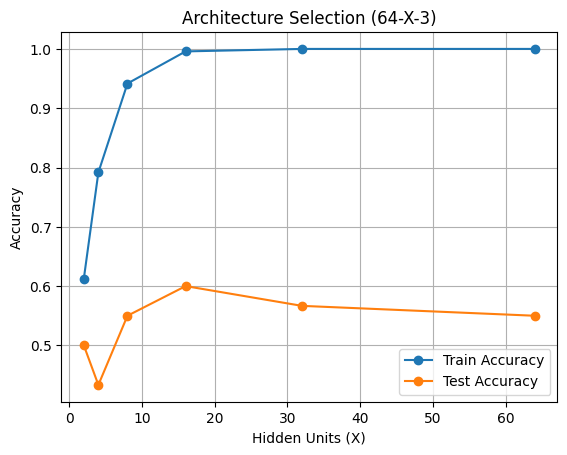

In [7]:

plt.plot(hidden_sizes, train_acc, marker='o', label='Train Accuracy')
plt.plot(hidden_sizes, test_acc, marker='o', label='Test Accuracy')

plt.xlabel("Hidden Units (X)")
plt.ylabel("Accuracy")
plt.title("Architecture Selection (64-X-3)")
plt.legend()
plt.grid()
plt.show()


In [8]:

best_h = hidden_sizes[np.argmax(test_acc)]
print("Best hidden units:", best_h)


Best hidden units: 16


In [9]:

train_sizes = [30, 60, 120, 180, 240]
sample_acc = []

for size in train_sizes:
    model = MLPClassifier(hidden_layer_sizes=(best_h,), max_iter=500, random_state=SEED)
    model.fit(X_train[:size], y_train[:size])
    preds = model.predict(X_test)

    sample_acc.append(accuracy_score(y_test, preds))


C:\Users\Sanket Bobhate\AppData\Roaming\Python\Python311\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


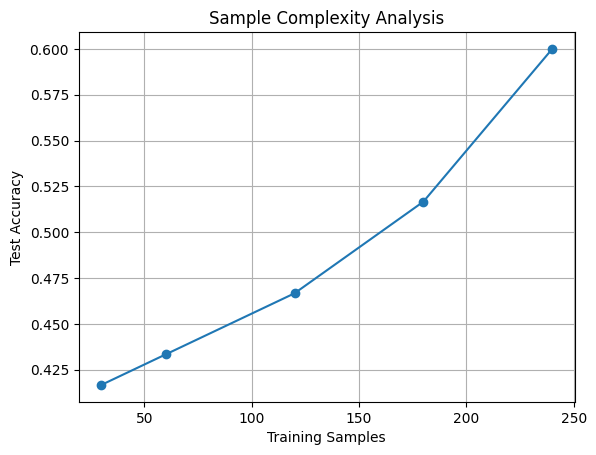

In [10]:

plt.plot(train_sizes, sample_acc, marker='o')

plt.xlabel("Training Samples")
plt.ylabel("Test Accuracy")
plt.title("Sample Complexity Analysis")
plt.grid()
plt.show()



## Conclusion

- Best architecture is 64-16-3 
- Small x<16 → Underfitting
- Large x>32 Overfitting
- Increasing data improves performance (sample complexity)
